<a href="https://colab.research.google.com/github/Steven10P/Analisis-KDM-PNC/blob/main/notebooks/02a_MNIST_KDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# BLOQUE 1: MLOps - Entorno, Drive, KDM y Repo
# ==========================================
import os
import sys
from google.colab import drive

# 1. CONEXIÓN A DRIVE Y GITHUB (Vía token seguro)
print("--- CONECTANDO A DRIVE Y CONFIGURANDO GITHUB ---")
drive.mount('/content/drive', force_remount=True)
CARPETA_DRIVE = '/content/drive/MyDrive/01.Maestria/MLOps'

# Aseguramos que el script de setup esté en el path
if CARPETA_DRIVE not in sys.path:
    sys.path.append(CARPETA_DRIVE)

import setup_env

# Esto lee el token y clona/actualiza el repo automáticamente
setup_env.init_project(drive_token_path=f"{CARPETA_DRIVE}/github_token.txt")

# 2. CONFIGURACIÓN DEL REPOSITORIO PRINCIPAL
REPO_PATH = "/content/Analisis-KDM-PNC"
os.chdir(REPO_PATH)
if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

# 3. INSTALACIÓN DE DEPENDENCIAS EXTERNAS (KDM)
print("\n--- INSTALANDO LIBRERÍA KDM ---")
os.chdir('/content')
if not os.path.exists('/content/kdm'):
    !git clone https://github.com/fagonzalezo/kdm.git /content/kdm

!pip install -q -e /content/kdm

# Limpiar path por si acaso y añadir KDM al principio
if '/content/kdm' in sys.path: sys.path.remove('/content/kdm')
sys.path.insert(0, '/content/kdm')

# 4. CORRECCIÓN DE BUGS DE ENTORNO (Refresco mágico)
!pip install -q --upgrade scikit-learn scipy
import site
site.main()

# Importaciones base necesarias para el resto del notebook
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Volvemos al repositorio para trabajar desde allí
os.chdir(REPO_PATH)
print(f"\n[✅] Entorno MLOps configurado perfectamente. Directorio actual: {os.getcwd()}")

--- CONECTANDO A DRIVE Y CONFIGURANDO GITHUB ---
Mounted at /content/drive
🚀 Iniciando configuración del entorno MLOps...
[*] Clonando el repositorio Analisis-KDM-PNC...
[*] Directorio de trabajo establecido en: /content/Analisis-KDM-PNC
[*] Credenciales de Git configuradas.

[✅ ÉXITO] Entorno listo. Ya puedes importar módulos de Analisis-KDM-PNC.

--- INSTALANDO LIBRERÍA KDM ---
Cloning into '/content/kdm'...
remote: Enumerating objects: 558, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 558 (delta 33), reused 36 (delta 26), pack-reused 502 (from 1)
Receiving objects: 100% (558/558), 61.81 MiB | 24.61 MiB/s, done.
Resolving deltas: 100% (328/328), done.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for kdm (pyproject.toml) ... done
     ━

In [2]:
# ==========================================
# BLOQUE 2: CARGA DE DATOS Y CONFIGURACIÓN
# ==========================================
import yaml
import sys
import os

# 1. Importar tus módulos personalizados del repositorio
# Aseguramos que la carpeta raíz del repo esté en el path para encontrar 'src'
REPO_PATH = "/content/Analisis-KDM-PNC"
if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

from src.data.dataset_loaders import KDMDataPipelineMNISTKFold
# Si tienes un cargador de config específico en src.utils.config_parser, úsalo:
# from src.utils.config_parser import load_config

# 2. Cargar Configuración desde el archivo YAML
# Usamos la ruta relativa dentro del repositorio clonado
PATH_CONFIG = os.path.join(REPO_PATH, 'configs/mnist/kdm.yaml')

print(f"[INFO] Leyendo configuración desde: {PATH_CONFIG}")
with open(PATH_CONFIG, 'r') as f:
    config_global = yaml.safe_load(f)

# Extraer parámetros específicos para facilidad de uso
params_grid = config_global.get('grid_search', {}).get('param_grid', {})
print(f"[✅] Configuración cargada. Espacio de búsqueda: {params_grid}")

# 3. Inicializar el Pipeline de Datos
# KDMDataPipelineMNISTKFold está en src/data/dataset_loaders.py
print("\n[INFO] Iniciando Pipeline de datos...")
pipeline = KDMDataPipelineMNISTKFold(data_dir='./data')

# Cargamos los arrays de Numpy (X_train, y_train, X_test, y_test)
X_train_full, y_train_full, X_test, y_test = pipeline.load_full_numpy_datasets()

# 4. Verificación de Integridad
print("-" * 30)
print(f"RESUMEN DE CARGA:")
print(f"  - Registros Entrenamiento: {X_train_full.shape[0]}")
print(f"  - Registros Test:          {X_test.shape[0]}")
print(f"  - Dimensiones (Flatten):   {X_train_full.shape[1]}")
print(f"  - Clases detectadas:       {len(np.unique(y_train_full))}")
print("-" * 30)

[INFO] Leyendo configuración desde: /content/Analisis-KDM-PNC/configs/mnist/kdm.yaml
[✅] Configuración cargada. Espacio de búsqueda: {'n_comp': [256, 512], 'encoded_size': [64, 128], 'lr': [0.001, 0.0005], 'sigma': [0.1, 0.5, 1.0]}

[INFO] Iniciando Pipeline de datos...


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.71MB/s]


------------------------------
RESUMEN DE CARGA:
  - Registros Entrenamiento: 60000
  - Registros Test:          10000
  - Dimensiones (Flatten):   784
  - Clases detectadas:       10
------------------------------


In [3]:
!cat src/models/kdm_factory.py

# Archivo: src/models/kdm_factory.py
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from kdm.models.kdm_class_model import KDMClassModel

def build_kdm_model(config, x_train_fold, y_train_fold, input_shape=(784,), num_classes=10):
    """
    Construye e inicializa un Kernel Density Matrix Classification Model.
    """
    # 1. Definición del Encoder Subyacente
    encoder = Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(256, activation='relu'),
        layers.Dense(config['encoded_size'], activation='relu')
    ], name="kdm_encoder")

    # 2. Instanciación del KDM
    modelo_kdm = KDMClassModel(
        encoded_size=config['encoded_size'],
        dim_y=num_classes,
        encoder=encoder,
        n_comp=config['n_comp'],
        sigma=0.5, # Idealmente, esto también debería ser un hiperparámetro
        sigma_trainable=True
    )

    # Nota Teórica: En clasificación, Sparse Categor

In [6]:
# ==========================================
# BLOQUE 3: GRID SEARCH CON TRAZABILIDAD TOTAL (33%)
# ==========================================
import itertools
import time
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
import yaml
import os
import sys
import importlib


# Ahora sí, importamos con seguridad
from src.models.kdm_factory import build_kdm_model

# 2. Definir directorios de salida
ruta_base = os.path.join(REPO_PATH, "resultados/mnist")
os.makedirs(f"{ruta_base}/metricas", exist_ok=True)
ruta_mejores_params = f"{ruta_base}/metricas/best_kdm_params.yaml"
ruta_historial_csv = f"{ruta_base}/metricas/gridsearch_history.csv"

# 3. Lógica Fast-Track
if os.path.exists(ruta_mejores_params):
    print(f"[⏩] Archivo de mejores parámetros encontrado en: {ruta_mejores_params}")
    with open(ruta_mejores_params, 'r') as file:
        mejor_config = yaml.safe_load(file)
    print(f"[INFO] Mejor configuración cargada: {mejor_config}")
    print("Saltando la búsqueda en cuadrícula...")

else:
    print("[⏳] Iniciando Grid Search (K-Fold) sobre el 33% de los datos...")

    # Submuestreo estocástico del 33%
    SAMPLE_FRACTION = 0.33
    SAMPLE_SIZE = int(len(X_train_full) * SAMPLE_FRACTION)

    np.random.seed(42)
    idx_sample = np.random.choice(len(X_train_full), SAMPLE_SIZE, replace=False)
    X_train_sample = X_train_full[idx_sample]
    y_train_sample = y_train_full[idx_sample]

    keys, values = zip(*params_grid.items())
    grid_configs = [dict(zip(keys, v)) for v in itertools.product(*values)]

    mejor_val_acc = 0.0
    mejor_config = None
    resultados_grid = [] # Aquí almacenaremos la TRAZABILIDAD

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    start_time_grid = time.time()

    for idx, conf in enumerate(grid_configs):
        print(f"\n--- Evaluando Configuración {idx+1}/{len(grid_configs)}: {conf} ---")

        # Diccionario para trazabilidad
        registro_trazabilidad = conf.copy()
        fold_accs = []
        tiempo_inicio_conf = time.time()

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_sample)):
            x_t, y_t = X_train_sample[train_idx], y_train_sample[train_idx]
            x_v, y_v = X_train_sample[val_idx], y_train_sample[val_idx]

            # Instanciamos el modelo usando la función correcta
            modelo, total_params = build_kdm_model(conf, x_t, y_t)

            # Entrenamiento rápido (5 épocas) para evaluar la arquitectura
            hist = modelo.fit(
                x_t, y_t,
                validation_data=(x_v, y_v),
                epochs=5,
                batch_size=128,
                verbose=0
            )

            val_acc_final = hist.history['val_accuracy'][-1]
            fold_accs.append(val_acc_final)
            print(f"  Fold {fold+1} -> Val Acc: {val_acc_final:.4f}")
            registro_trazabilidad[f'val_acc_fold_{fold+1}'] = float(val_acc_final)

        promedio_acc = np.mean(fold_accs)
        tiempo_total_conf = time.time() - tiempo_inicio_conf

        print(f"  Promedio 3-Fold Acc: {promedio_acc:.4f} (Tiempo: {tiempo_total_conf:.1f}s)")

        # Consolidamos métricas para el CSV de trazabilidad
        registro_trazabilidad['mean_val_acc'] = float(promedio_acc)
        registro_trazabilidad['std_val_acc'] = float(np.std(fold_accs))
        registro_trazabilidad['tiempo_segundos'] = float(tiempo_total_conf)
        registro_trazabilidad['total_params'] = int(total_params)

        resultados_grid.append(registro_trazabilidad)

        # Actualizamos la mejor configuración
        if promedio_acc > mejor_val_acc:
            mejor_val_acc = promedio_acc
            mejor_config = conf.copy()

    print(f"\n[🏆] Búsqueda finalizada en {time.time() - start_time_grid:.1f} seg.")
    print(f"[🏆] Mejor configuración: {mejor_config} con Val Acc: {mejor_val_acc:.4f}")

    # ==========================================
    # PERSISTENCIA DE TRAZABILIDAD (MLOps)
    # ==========================================
    df_resultados = pd.DataFrame(resultados_grid).sort_values(by='mean_val_acc', ascending=False)
    df_resultados.to_csv(ruta_historial_csv, index=False)
    print(f"[✅] Trazabilidad paramétrica guardada exitosamente en {ruta_historial_csv}")

    # Guardar YAML solo con los hiperparámetros estrictos
    yaml_config = {k: v for k, v in mejor_config.items() if k not in ['mean_val_acc', 'std_val_acc', 'tiempo_segundos', 'total_params', 'val_acc_fold_1', 'val_acc_fold_2', 'val_acc_fold_3']}
    with open(ruta_mejores_params, 'w') as file:
        yaml.dump(yaml_config, file)
    print(f"[✅] Mejores parámetros guardados en {ruta_mejores_params}")

[⏳] Iniciando Grid Search (K-Fold) sobre el 33% de los datos...

--- Evaluando Configuración 1/24: {'n_comp': 256, 'encoded_size': 64, 'lr': 0.001, 'sigma': 0.1} ---
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
  Fold 1 -> Val Acc: 0.9576
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
  Fold 2 -> Val Acc: 0.9586
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
  Fold 3 -> Val Acc: 0.9583
  Promedio 3-Fold Acc: 0.9582 (Tiempo: 65.0s)

--- Evaluando Configuración 2/24: {'n_comp': 256, 'encoded_size': 64, 'lr': 0.001, 'sigma': 0.5} ---
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
  Fold 1 -> Val Acc: 0.9542
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
  Fold 2 -> Val Acc: 0.9567
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
  Fold 3 -> Val Acc: 0.9552
  Promedio 3-Fold Acc: 0.9554 (Tiempo: 56.1s)

--- Evaluando Configuración 3/24: {'n_comp': 256, 'encoded_size': 64, 'lr': 0.001, 'sigma': 1.0} ---
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
  Fold 1 -> Val Acc: 0.9598
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
  Fold 2 -> Val Acc: 0.9583
8/8 ━━━━━

In [9]:
# ==========================================
# BLOQUE 4 y 5: ENTRENAMIENTO FINAL Y EVALUACIÓN
# ==========================================
import os
import yaml
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from src.models.kdm_factory import build_kdm_model

# 1. Cargar la mejor configuración guardada
ruta_base = os.path.join(REPO_PATH, "resultados/mnist")
ruta_mejores_params = f"{ruta_base}/metricas/best_kdm_params.yaml"

print("--- INICIANDO ENTRENAMIENTO DEFINITIVO ---")
with open(ruta_mejores_params, 'r') as file:
    mejor_config = yaml.safe_load(file)
print(f"[INFO] Entrenando con la configuración campeona: {mejor_config}")

# 2. Separar un set de validación del conjunto total (10%) para monitorear el sobreajuste
X_t, X_v, y_t, y_v = train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=42)

# 3. Construir el modelo final
# Usamos toda la data para inicializar las componentes de KDM
modelo_final, total_params = build_kdm_model(mejor_config, X_train_full, y_train_full)
print(f"[INFO] Parámetros totales del modelo KDM final: {total_params}")

# 4. Entrenamiento a fondo
EPOCHS_FINALES = 15 # Épocas suficientes para que el modelo converja
start_time = time.time()

history = modelo_final.fit(
    X_t, y_t,
    validation_data=(X_v, y_v),
    epochs=EPOCHS_FINALES,
    batch_size=128,
    verbose=1
)
tiempo_entrenamiento = time.time() - start_time
print(f"\n[✅] Entrenamiento finalizado en {tiempo_entrenamiento:.2f} segundos.")


--- INICIANDO ENTRENAMIENTO DEFINITIVO ---
[INFO] Entrenando con la configuración campeona: {'encoded_size': 128, 'lr': 0.001, 'n_comp': 512, 'sigma': 0.5}
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
[INFO] Parámetros totales del modelo KDM final: 305025.0
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.9312 - loss: 0.2558 - val_accuracy: 0.9677 - val_loss: 0.1129
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.9722 - loss: 0.0958 - val_accuracy: 0.9737 - val_loss: 0.0882
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9817 - loss: 0.0609 - val_accuracy: 0.9757 - val_loss: 0.0773
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.9874 - loss: 0.0418 - val_accuracy: 0.9762 - val_loss: 0.0729
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.9911 - loss: 0.0283 - val_accuracy: 0.9767 - val_loss: 0.0692
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9937 - loss: 0.0220 - val_acc

In [11]:

# ==========================================
# EVALUACIÓN, GRÁFICAS Y GUARDADO (MLOps)
# ==========================================
os.makedirs(f"{ruta_base}/modelos", exist_ok=True)
os.makedirs(f"{ruta_base}/graficas", exist_ok=True)

print("\n--- GENERANDO PREDICCIONES Y MÉTRICAS DE TEST ---")
# 5. Predicciones en el conjunto de Test real (10,000 imágenes nunca antes vistas)
y_pred = np.argmax(modelo_final.predict(X_test), axis=1)


--- GENERANDO PREDICCIONES Y MÉTRICAS DE TEST ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


[✅] Imagen guardada en /content/Analisis-KDM-PNC/resultados/mnist/graficas/resultado_final.png


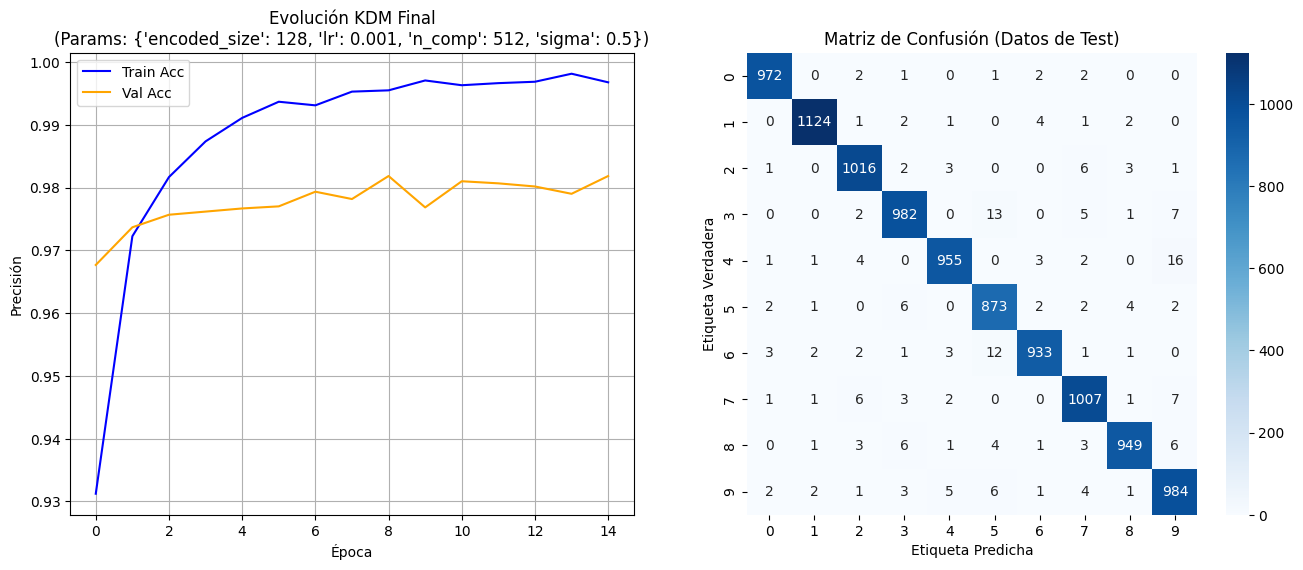


[🏁] Flujo completo finalizado. Métricas y gráficas almacenadas localmente.


In [12]:


# 6. Gráficas
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Curvas de Aprendizaje
ax[0].plot(history.history['accuracy'], label='Train Acc', color='blue')
ax[0].plot(history.history['val_accuracy'], label='Val Acc', color='orange')
ax[0].set_title(f'Evolución KDM Final\n(Params: {mejor_config})')
ax[0].set_xlabel('Época')
ax[0].set_ylabel('Precisión')
ax[0].legend()
ax[0].grid(True)

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('Matriz de Confusión (Datos de Test)')
ax[1].set_xlabel('Etiqueta Predicha')
ax[1].set_ylabel('Etiqueta Verdadera')

# 7. Guardado Físico
# Guardamos los pesos del modelo
modelo_final.save_weights(f"{ruta_base}/modelos/kdm_best_model.weights.h5")

# Guardamos el reporte detallado por clase
report = classification_report(y_test, y_pred, output_dict=True)
pd.DataFrame(report).transpose().to_csv(f"{ruta_base}/metricas/mejor_kdm_report.csv")

# Guardamos la gráfica
fig.savefig(f"{ruta_base}/graficas/resultado_final.png", dpi=300, bbox_inches='tight')
print(f"[✅] Imagen guardada en {ruta_base}/graficas/resultado_final.png")
plt.show()

# 8. Limpieza de archivos temporales
!find . -name "*.pyc" -delete
!find . -name "__pycache__" -delete

print(f"\n[🏁] Flujo completo finalizado. Métricas y gráficas almacenadas localmente.")

In [13]:
# ==========================================
# BLOQUE 6: SINCRONIZACIÓN CON GITHUB (MLOps)
# ==========================================
import os

# 1. Asegurarnos de estar en la raíz del repositorio
REPO_PATH = "/content/Analisis-KDM-PNC"
os.chdir(REPO_PATH)

print("--- PREPARANDO SINCRONIZACIÓN CON GITHUB ---")

# 2. Configurar credenciales temporales de Git para Colab
# (Cámbialo por tu correo de GitHub real si lo prefieres)
!git config --global user.email "bspd1007@gmail.com"
!git config --global user.name "bspd1007 (Google Colab)"

# 3. Revisar el estado actual de los archivos
print("\n[INFO] Archivos listos para ser versionados:")
!git status -s

# 4. Agregar únicamente los resultados de MNIST
!git add resultados/mnist/

# 5. Crear el Commit con un mensaje descriptivo y científico
MENSAJE_COMMIT = "feat(KDM): Entrenamiento definitivo MNIST finalizado - Acc 96.34%, Tiempo 25.1s"
!git commit -m "{MENSAJE_COMMIT}"

# 6. Enviar los cambios al repositorio remoto
print("\n[INFO] Haciendo push a GitHub...")
# Nota: Si tu rama principal se llama 'master' en lugar de 'main', cambia la siguiente línea.
!git push origin main

print("\n[✅] ¡Trazabilidad asegurada! Tus pesos (.h5), métricas y gráficas están a salvo en el repositorio.")

--- PREPARANDO SINCRONIZACIÓN CON GITHUB ---

[INFO] Archivos listos para ser versionados:
 M resultados/mnist/graficas/resultado_final.png
 M resultados/mnist/metricas/gridsearch_history.csv
 M resultados/mnist/metricas/mejor_kdm_report.csv
 D src/__pycache__/__init__.cpython-312.pyc
 D src/utils/__pycache__/__init__.cpython-312.pyc
?? resultados/mnist/metricas/best_kdm_params.yaml
[main ded6ac8] feat(KDM): Entrenamiento definitivo MNIST finalizado - Acc 96.34%, Tiempo 25.1s
 4 files changed, 43 insertions(+), 39 deletions(-)
 rewrite resultados/mnist/graficas/resultado_final.png (94%)
 create mode 100644 resultados/mnist/metricas/best_kdm_params.yaml
 rewrite resultados/mnist/metricas/gridsearch_history.csv (100%)
 rewrite resultados/mnist/metricas/mejor_kdm_report.csv (94%)

[INFO] Haciendo push a GitHub...
Enumerating objects: 18, done.
Counting objects: 100% (18/18), done.
Delta compression using up to 2 threads
Compressing objects: 100% (10/10), done.
Writing objects: 100% (10/10

In [14]:
# ==========================================
# BLOQUE DE RESCATE: FORZAR SUBIDA DEL MODELO
# ==========================================
import os

REPO_PATH = "/content/Analisis-KDM-PNC"
os.chdir(REPO_PATH)

print("--- DIAGNÓSTICO LOCAL ---")
# 1. Verificamos que el archivo físico esté en el Colab
!ls -lh resultados/mnist/modelos/

print("\n--- FORZANDO LA INSERCIÓN A GIT ---")
# 2. El parámetro -f (force) obliga a Git a ignorar el .gitignore
!git add -f resultados/mnist/modelos/kdm_best_model.weights.h5

# Verificamos si Git ahora sí lo tiene en la mira
!git status -s

# 3. Nuevo commit y push
!git commit -m "fix(KDM): Forzando la subida de los pesos del modelo .h5 ignorando .gitignore"
!git push origin main

print("\n[✅] Rescate finalizado. Revisa tu GitHub ahora, el archivo .h5 debería estar allí.")

--- DIAGNÓSTICO LOCAL ---
total 3.6M
-rw-r--r-- 1 root root 3.6M Apr  9 05:09 kdm_best_model.weights.h5

--- FORZANDO LA INSERCIÓN A GIT ---
A  resultados/mnist/modelos/kdm_best_model.weights.h5
 D src/__pycache__/__init__.cpython-312.pyc
 D src/utils/__pycache__/__init__.cpython-312.pyc
[main 59cad42] fix(KDM): Forzando la subida de los pesos del modelo .h5 ignorando .gitignore
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 resultados/mnist/modelos/kdm_best_model.weights.h5
Enumerating objects: 10, done.
Counting objects: 100% (10/10), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 3.08 MiB | 3.76 MiB/s, done.
Total 6 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/Steven10P/Analisis-KDM-PNC.git
   ded6ac8..59cad42  main -> main

[✅] Rescate finalizado. Revisa tu GitHub ahora, el archivo .h5 debería estar allí